# E1.3 — Autocorrelation Checkpoint (Paper 1 extension)

Sampling-adequacy gate for Phase E1. After the nine first-replicate 100 ns trajectories
(E1.2) are in, this estimates the integrated autocorrelation time (tau_int) of the reported
observable — motif SASA — and of the radius of gyration (the slow conformational mode behind
the compact-vs-extended concern), to decide whether 100 ns is long enough before committing
the remaining replicates (E2).

**Decision rule (resolved design):** if the glyceline systems show motif-SASA tau_int > 5 ns,
extend the trajectory length before running rep2/rep3. Otherwise 100 ns proceeds.

**What it reports per trajectory:** tau_int (ns) for SASA and Rg, effective sample size
N_eff = N / tau_int, the CI inflation factor sqrt(tau_int), and a reliability flag — a
tau_int estimate is only trustworthy when the trajectory spans many correlation times
(T >= 50 tau_int), so this also tells you whether 100 ns is even long enough to *estimate*
tau_int, not just whether it samples adequately.

**Method:** FFT autocorrelation with Sokal automated windowing (tau_int = 1 + 2 sum rho(k),
windowed at W >= c tau_int(W), c=5). Validated against AR(1) processes (recovers known
tau_int to ~1%). This is the same estimator E3.1 uses for the corrected CIs.

Runnable on whatever trajectories are complete — it auto-discovers them — so you can run it on
GGE_water rep1 now as a first data point and re-run as the batches land. The glyceline verdict
is pending until those systems are present.

## 1 — Imports
**Out:** namespace.

In [1]:
import re, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt

print(f"MDTraj {md.__version__}")

MDTraj 1.11.1


## 2 — Configuration
**Out:** paths, analysis parameters.

In [2]:
PROJECT_DIR = Path("~/des-peptide-study").expanduser()
SYSTEMS_DIR = PROJECT_DIR / "systems"
TRAJ_DIR    = PROJECT_DIR / "extension" / "trajectories"
FIG_DIR     = PROJECT_DIR / "extension" / "analysis" / "autocorrelation_checkpoint"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SAVE_INTERVAL_PS = 1.0     # production DCD save interval
STRIDE           = 10      # analyse every 10th frame (10 ps) — resolves ns-scale correlations
EQUIL_DISCARD_NS = 10.0    # conservative equilibration discard before tau_int
WINDOW_C         = 5.0     # Sokal windowing constant
TAU_THRESHOLD_NS = 5.0     # glyceline SASA tau_int above this triggers length extension
RELIABILITY_MIN  = 50      # need T >= RELIABILITY_MIN * tau_int for a trustworthy estimate

THREE_TO_ONE = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E',
                'GLY':'G','HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F',
                'PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'}

## 3 — Discover completed trajectories
Globs the trajectory directory for `{system}_rep{N}/{tag}.dcd`, pairs each with its topology,
and flags whether a verified metadata record exists. Run whenever; it picks up new runs.
**Out:** `COMPLETED` (list of dicts).

In [3]:
def resolve_prmtop(system):
    for cand in (SYSTEMS_DIR / system / f"{system}.prmtop", SYSTEMS_DIR / f"{system}.prmtop"):
        if cand.exists():
            return cand
    return None

COMPLETED = []
for dcd in sorted(TRAJ_DIR.glob("*/*.dcd")):
    m = re.match(r"(.+)_rep(\d+)$", dcd.stem)
    if not m:
        continue
    system, replica = m.group(1), int(m.group(2))
    prm = resolve_prmtop(system)
    if prm is None:
        print(f"[skip] {dcd.stem}: no topology found")
        continue
    meta = dcd.with_name(f"{dcd.stem}_metadata.json")
    verified = None
    if meta.exists():
        verified = json.loads(meta.read_text()).get("verified")
    COMPLETED.append({"system": system, "replica": replica, "tag": dcd.stem,
                      "dcd": dcd, "prmtop": prm, "verified": verified})

print(f"{len(COMPLETED)} trajectory(ies) found:")
for c in COMPLETED:
    print(f"  {c['tag']:<22} verified={c['verified']}")
print(f"\nEstimated cost: ~2-4 min per trajectory (strided load + Shrake-Rupley SASA).")

5 trajectory(ies) found:
  CME_glyceline_rep1     verified=True
  CME_water_rep1         verified=True
  GGE_glyceline_rep1     verified=True
  GGE_water_rep1         verified=None
  YIY_water_rep1         verified=True

Estimated cost: ~2-4 min per trajectory (strided load + Shrake-Rupley SASA).


## 4 — Autocorrelation estimator
FFT autocorrelation and Sokal automated windowing. `integrated_time` returns tau_int in frame
units; `tau_curve` exposes the cumulative tau_int(W) for the diagnostic plot.

In [4]:
def autocorr_func_1d(x):
    x = np.asarray(x, float); x = x - x.mean()
    n = len(x)
    nfft = 1
    while nfft < 2 * n:
        nfft *= 2
    f = np.fft.fft(x, n=nfft)
    acf = np.fft.ifft(f * np.conjugate(f))[:n].real
    acf /= acf[0]
    return acf

def auto_window(taus, c=WINDOW_C):
    m = np.arange(len(taus)) < c * taus
    if np.any(m):
        return int(np.argmin(m))
    return len(taus) - 1

def tau_curve(x):
    taus = 2.0 * np.cumsum(autocorr_func_1d(x)) - 1.0
    return taus, auto_window(taus)

def integrated_time(x):
    taus, w = tau_curve(x)
    return taus[w], w

## 5 — Observable extraction
Loads the trajectory strided, isolates the peptide, and returns the motif total SASA and the
peptide radius of gyration per frame.
**In:** dcd, prmtop, motif sequence. **Out:** `sasa(t)`, `rg(t)`.

In [5]:
def compute_observables(dcd, prmtop, motif_seq, stride):
    traj = md.load(str(dcd), top=str(prmtop), stride=stride)
    sel = traj.topology.select("protein")
    if len(sel) == 0:
        sel = traj.topology.select("not (water or resname HOH WAT CHO CLA URE GOL NA CL Na+ Cl-)")
    prot = traj.atom_slice(sel)

    seq = "".join(THREE_TO_ONE.get(r.name, "X") for r in prot.topology.residues)
    pos = seq.find(motif_seq)
    if pos < 0:
        raise ValueError(f"motif {motif_seq} not found in peptide sequence {seq}")
    motif_idx = list(range(pos, pos + len(motif_seq)))

    sasa = md.shrake_rupley(prot, mode="residue")[:, motif_idx].sum(axis=1)  # nm^2
    rg = md.compute_rg(prot)                                                 # nm
    return sasa, rg, seq

## 6 — Per-trajectory analysis
For each completed trajectory: extract observables, discard the equilibration window, and
estimate tau_int, N_eff, the CI inflation factor, and the reliability flag for SASA and Rg.
**In:** `COMPLETED`. **Out:** `df` (results), `series` (cached time series for plotting).

In [6]:
dt_ps = SAVE_INTERVAL_PS * STRIDE
n_equil = int(EQUIL_DISCARD_NS * 1000.0 / dt_ps)

rows, series = [], {}
for c in COMPLETED:
    motif = c["system"].split("_")[0]
    print(f"analysing {c['tag']} (motif {motif}) ...", end=" ", flush=True)
    t0 = time.time()
    sasa, rg, seq = compute_observables(c["dcd"], c["prmtop"], motif, STRIDE)
    series[c["tag"]] = {"sasa": sasa, "rg": rg}

    for obs_name, full in (("SASA", sasa), ("Rg", rg)):
        s = full[n_equil:]
        tau_f, w = integrated_time(s)
        tau_f = max(tau_f, 1.0)
        tau_ns = tau_f * dt_ps / 1000.0
        n_eff = len(s) / tau_f
        ci_infl = np.sqrt(tau_f)
        T_over_tau = len(s) / tau_f
        rows.append({
            "system": c["system"], "replica": c["replica"], "observable": obs_name,
            "tau_int_ns": round(tau_ns, 3), "N_eff": round(n_eff, 1),
            "CI_inflation": round(ci_infl, 1), "T_over_tau": round(T_over_tau, 1),
            "reliable": T_over_tau >= RELIABILITY_MIN,
            "n_analysed_frames": len(s), "mean": round(float(s.mean()), 4),
        })
    print(f"done ({time.time()-t0:.0f}s)")

df = pd.DataFrame(rows)
print()
print(df.to_string(index=False) if len(df) else "No trajectories analysed yet.")

analysing CME_glyceline_rep1 (motif CME) ... done (25s)
analysing CME_water_rep1 (motif CME) ... done (25s)
analysing GGE_glyceline_rep1 (motif GGE) ... done (20s)
analysing GGE_water_rep1 (motif GGE) ... done (21s)
analysing YIY_water_rep1 (motif YIY) ... done (18s)

       system  replica observable  tau_int_ns  N_eff  CI_inflation  T_over_tau  reliable  n_analysed_frames   mean
CME_glyceline        1       SASA       5.297   17.0          23.0        17.0     False               9000 3.7705
CME_glyceline        1         Rg       4.163   21.6          20.4        21.6     False               9000 0.6998
    CME_water        1       SASA       1.515   59.4          12.3        59.4      True               9000 3.8815
    CME_water        1         Rg       7.051   12.8          26.6        12.8     False               9000 0.7919
GGE_glyceline        1       SASA       9.990    9.0          31.6         9.0     False               9000 2.6853
GGE_glyceline        1         Rg       3

## 7 — Decision verdict
Applies the resolved rule to the glyceline systems' motif-SASA tau_int. Until glyceline
trajectories are present, the verdict is pending and this just summarises what is in hand.

In [7]:
if len(df) == 0:
    print("No data yet.")
else:
    sasa_df = df[df["observable"] == "SASA"]
    print("Motif-SASA autocorrelation summary")
    print("-" * 60)
    for _, r in sasa_df.iterrows():
        flag = "" if r["reliable"] else "  [estimate uncertain: T < 50 tau]"
        print(f"  {r['system']:<16} rep{r['replica']}: tau_int = {r['tau_int_ns']:.2f} ns, "
              f"N_eff = {r['N_eff']:.0f}{flag}")
    print("-" * 60)

    gly = sasa_df[sasa_df["system"].str.contains("glyceline")]
    if len(gly) == 0:
        print("VERDICT: PENDING — no glyceline trajectory analysed yet.")
        print("The decision keys on glyceline motif-SASA tau_int once those runs are in.")
    else:
        worst = gly["tau_int_ns"].max()
        if worst > TAU_THRESHOLD_NS:
            print(f"VERDICT: EXTEND — glyceline SASA tau_int reaches {worst:.2f} ns "
                  f"(> {TAU_THRESHOLD_NS:g} ns threshold). Lengthen trajectories before rep2/rep3.")
        else:
            print(f"VERDICT: 100 ns ADEQUATE — glyceline SASA tau_int peaks at {worst:.2f} ns "
                  f"(<= {TAU_THRESHOLD_NS:g} ns). Proceed with replicates at 100 ns.")
        if not gly["reliable"].all():
            print("CAUTION: at least one glyceline estimate has T < 50 tau — the tau_int itself "
                  "is uncertain at 100 ns, which is itself an argument for longer runs.")

Motif-SASA autocorrelation summary
------------------------------------------------------------
  CME_glyceline    rep1: tau_int = 5.30 ns, N_eff = 17  [estimate uncertain: T < 50 tau]
  CME_water        rep1: tau_int = 1.51 ns, N_eff = 59
  GGE_glyceline    rep1: tau_int = 9.99 ns, N_eff = 9  [estimate uncertain: T < 50 tau]
  GGE_water        rep1: tau_int = 4.51 ns, N_eff = 20  [estimate uncertain: T < 50 tau]
  YIY_water        rep1: tau_int = 2.85 ns, N_eff = 32  [estimate uncertain: T < 50 tau]
------------------------------------------------------------
VERDICT: EXTEND — glyceline SASA tau_int reaches 9.99 ns (> 5 ns threshold). Lengthen trajectories before rep2/rep3.
CAUTION: at least one glyceline estimate has T < 50 tau — the tau_int itself is uncertain at 100 ns, which is itself an argument for longer runs.


## 8 — Diagnostic plots
For each trajectory: the motif-SASA series and the cumulative tau_int(W) curve with the chosen
window marked. A tau_int read off a clean plateau is trustworthy; one taken while the curve is
still climbing is not. Saved to the checkpoint figures directory.

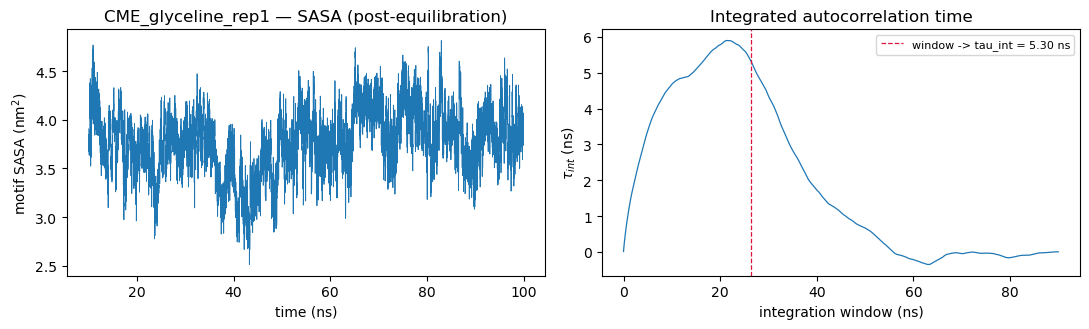

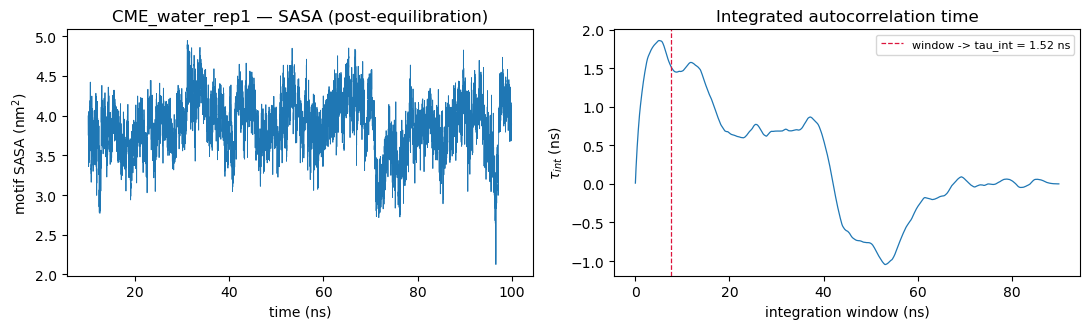

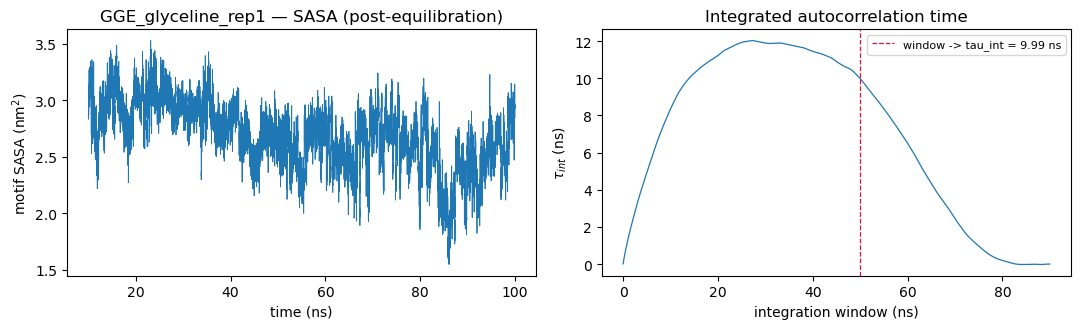

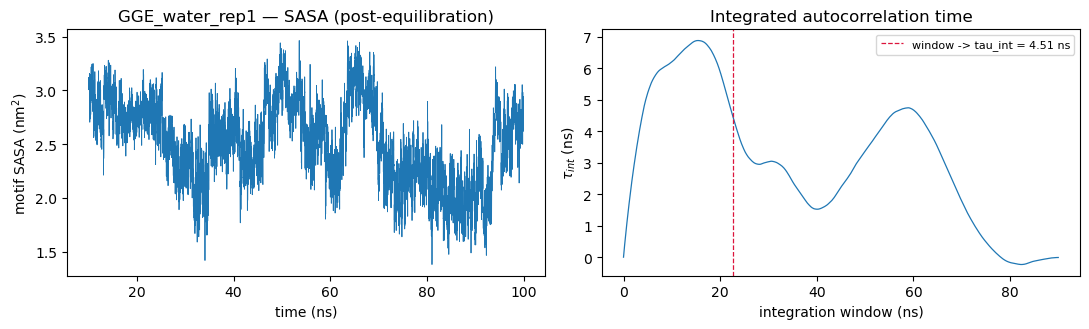

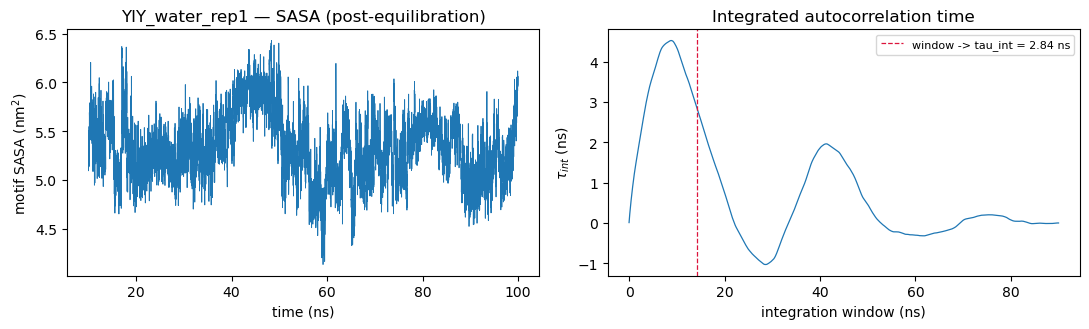

In [8]:
for c in COMPLETED:
    tag = c["tag"]
    sasa = series[tag]["sasa"][n_equil:]
    taus, w = tau_curve(sasa)
    t_ns = (np.arange(len(sasa)) * dt_ps + EQUIL_DISCARD_NS * 1000.0) / 1000.0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
    ax1.plot(t_ns, sasa, lw=0.6)
    ax1.set_xlabel("time (ns)"); ax1.set_ylabel("motif SASA (nm$^2$)")
    ax1.set_title(f"{tag} — SASA (post-equilibration)")

    lags_ns = np.arange(len(taus)) * dt_ps / 1000.0
    ax2.plot(lags_ns, taus * dt_ps / 1000.0, lw=0.9)
    ax2.axvline(w * dt_ps / 1000.0, color="crimson", ls="--", lw=0.9,
                label=f"window -> tau_int = {taus[w]*dt_ps/1000.0:.2f} ns")
    ax2.set_xlabel("integration window (ns)"); ax2.set_ylabel(r"$\tau_{int}$ (ns)")
    ax2.set_title("Integrated autocorrelation time"); ax2.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{tag}_tau_int.png", dpi=150)
    plt.show()

## 9 — Save results
Writes the per-trajectory table to CSV for the record and for E3.1 to reuse.
**Out:** `autocorrelation_checkpoint.csv`.

In [9]:
if len(df):
    out_csv = FIG_DIR / "autocorrelation_checkpoint.csv"
    df.to_csv(out_csv, index=False)
    print("saved:", out_csv)
    print(f"\n{len(COMPLETED)} trajectory(ies) analysed; "
          f"stride {STRIDE} ({dt_ps:g} ps), equilibration discard {EQUIL_DISCARD_NS:g} ns.")
else:
    print("Nothing to save yet.")

saved: /Users/rossgibson/des-peptide-study/extension/analysis/autocorrelation_checkpoint/autocorrelation_checkpoint.csv

5 trajectory(ies) analysed; stride 10 (10 ps), equilibration discard 10 ns.
